# Modeling & Training

## General Description

This notebook focuses on developing, training, and evaluating image classification models capable of identifying rice leaf diseases from images.

The notebook uses the processed datasets generated during preprocessing to train convolutional neural network (CNN) models for multi-class disease classification. Different modeling approaches and training configurations will be explored to identify a reliable and efficient solution for rice leaf disease prediction.

The notebook also includes model evaluation, performance visualization, and preparation of final artifacts for deployment in the Streamlit dashboard.


## Objectives

- Prepare TensorFlow image generators for model training.
- Build and train image classification models.
- Evaluate model performance on validation data.
- Analyze classification accuracy and prediction behavior.
- Compare training and validation performance.
- Identify potential overfitting or underfitting.
- Save trained models and evaluation outputs for deployment.


## Inputs

Processed datasets and metadata generated during preprocessing:

- `inputs/datasets/processed/train_labels.csv`
- `inputs/datasets/processed/val_labels.csv`

Raw image dataset:
- `inputs/datasets/raw/rice/`

Preprocessing outputs:
- `outputs/datasets/preprocessing/preprocessing_summary.csv`


## Outputs

Generated model artifacts and evaluation outputs saved to:

`outputs/models/`

Including:
- trained classification model
- training history
- evaluation metrics
- confusion matrix visualizations
- prediction examples


## Additional Comments

- Transfer learning will be considered to improve model performance and reduce training time.
- Dataset imbalance may affect classification accuracy for minority disease classes.
- Data augmentation strategies defined during preprocessing will be applied during training.
- Model performance will be evaluated using both quantitative metrics and visual analysis.

### 1. Load Python Packages and Project Dependencies

This section imports the libraries and dependencies required for image classification model development, training, evaluation, and visualization.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# File and path handling
from pathlib import Path
import os
import json

# Visualisation
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import (
    MobileNetV2
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

# Evaluation
from sklearn.metrics import accuracy_score

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


In [2]:
def setup_root():
    current_path = Path().resolve()
    # Search upwards for project root
    while not (current_path / "requirements.txt").exists():
        if current_path == current_path.parent:
            raise FileNotFoundError(
                "Project root not found."
            )
        current_path = current_path.parent
    return current_path


# Set project root
PROJECT_ROOT = setup_root()

# Change working directory
os.chdir(PROJECT_ROOT)
print(f"Project root set to: {PROJECT_ROOT}")


# Define paths
RAW_DATA_DIR = Path(
    "inputs/datasets/raw/rice"
)

PROCESSED_DATA_DIR = Path(
    "inputs/datasets/processed"
)

MODEL_OUTPUT_DIR = Path(
    "outputs/models"
)

MODEL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Processed dataset directory: "
      f"{PROCESSED_DATA_DIR}")

print(f"Model output directory: "
      f"{MODEL_OUTPUT_DIR}")

Project root set to: C:\code\ml\workspace\rice_leaf_diseases_analyser
Processed dataset directory: inputs\datasets\processed
Model output directory: outputs\models


### 3. Load Processed Datasets

Load the processed training and validation metadata generated during preprocessing. These datasets contain image paths and classification labels used during model training.

In [3]:
# Load processed datasets
train_labels_path = (
    PROCESSED_DATA_DIR / "train_labels.csv"
)

val_labels_path = (
    PROCESSED_DATA_DIR / "val_labels.csv"
)

df_train = pd.read_csv(train_labels_path)

df_val = pd.read_csv(val_labels_path)

print("Datasets loaded successfully.")

print(f"\nTraining samples: {len(df_train)}")
print(f"Validation samples: {len(df_val)}")

Datasets loaded successfully.

Training samples: 6935
Validation samples: 1730


In [4]:
# Preview training dataset
display(df_train.head())

# Preview validation dataset
display(df_val.head())

,image_path,class_id,class_name
0,inputs\datasets\raw\rice\images\train\r6k_test...,6,LeafSmut
1,inputs\datasets\raw\rice\images\train\r6k_test...,6,LeafSmut
2,inputs\datasets\raw\rice\images\train\r6k_test...,6,LeafSmut
3,inputs\datasets\raw\rice\images\train\r6k_test...,6,LeafSmut
4,inputs\datasets\raw\rice\images\train\r6k_test...,6,LeafSmut


,image_path,class_id,class_name
0,inputs\datasets\raw\rice\images\val\r6k_test_B...,6,LeafSmut
1,inputs\datasets\raw\rice\images\val\r6k_test_B...,6,LeafSmut
2,inputs\datasets\raw\rice\images\val\r6k_test_B...,6,LeafSmut
3,inputs\datasets\raw\rice\images\val\r6k_test_B...,6,LeafSmut
4,inputs\datasets\raw\rice\images\val\r6k_test_B...,6,LeafSmut


In [5]:
print("Training class distribution:\n")

print(
    df_train["class_name"]
    .value_counts()
)

print("\nValidation class distribution:\n")

print(
    df_val["class_name"]
    .value_counts()
)

Training class distribution:

class_name
LeafSmut               1600
BacterialLeafBlight    1600
BrownSpot              1600
LeafScald               365
NeckBlast               363
LeafBlast               360
NarrowBrownLeafSpot     355
Healthy                 347
Hispa                   345
Name: count, dtype: int64

Validation class distribution:

class_name
LeafSmut               400
BacterialLeafBlight    400
BrownSpot              400
LeafScald               91
NeckBlast               90
LeafBlast               89
NarrowBrownLeafSpot     88
Hispa                   86
Healthy                 86
Name: count, dtype: int64


### 4. Configure Image Data Generators

Create TensorFlow image generators for training and validation workflows. The generators will load images dynamically from the processed metadata tables and apply preprocessing and augmentation strategies during model training.

#### Define Image Generator Configuration

In [6]:
# Image configuration
IMAGE_SIZE = (224, 224)

# Training configuration
BATCH_SIZE = 32

print(f"Image size: {IMAGE_SIZE}")
print(f"Batch size: {BATCH_SIZE}")

Image size: (224, 224)
Batch size: 32


In [8]:
# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],

    fill_mode="nearest"
)

# Validation generator
val_datagen = ImageDataGenerator(
    rescale=1. / 255
)

# Training generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col="image_path",
    y_col="class_name",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

# Validation generator
val_generator = val_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col="image_path",
    y_col="class_name",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 6935 validated image filenames belonging to 9 classes.
Found 1730 validated image filenames belonging to 9 classes.


#### Inspect Generated Training Batch

In [9]:
# Load one batch
images, labels = next(train_generator)

print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 9)


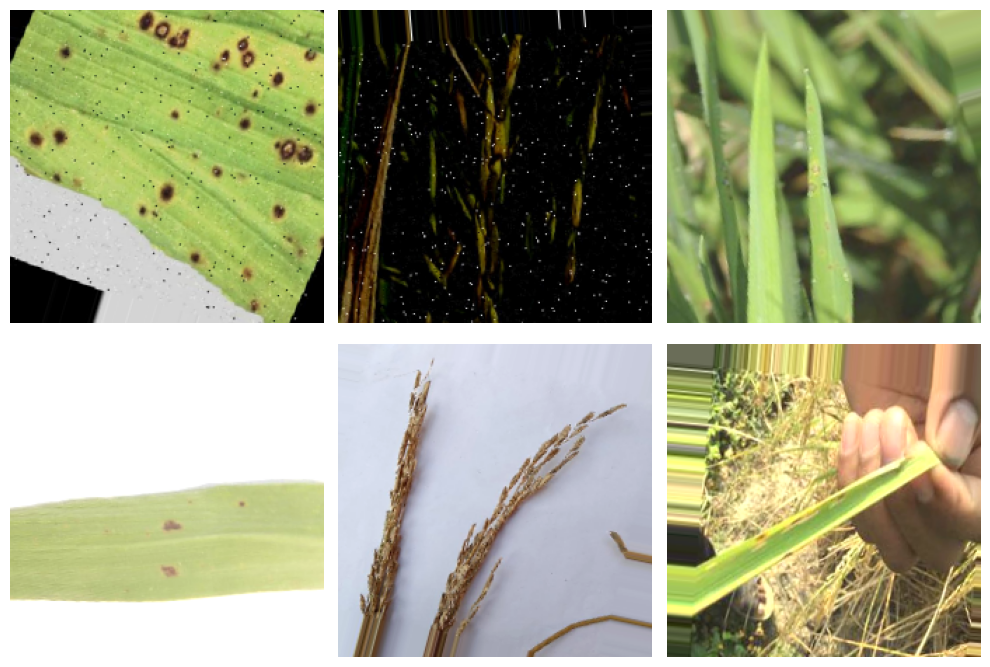

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for i, ax in enumerate(axes.flatten()):

    ax.imshow(images[i])

    ax.axis("off")

plt.tight_layout()
plt.show()

### 5. Build Baseline Classification Model

Build a baseline image classification model using transfer learning. A pretrained convolutional neural network will be used as the feature extraction backbone to improve training efficiency and model performance.

#### Configure Transfer Learning Backbone

In [12]:
# Load pretrained MobileNetV2 model
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

print("Base model loaded successfully.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Base model loaded successfully.


In [14]:
# Build classification model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(
        128,
        activation="relu"
    ),
    Dropout(0.2),
    Dense(
        len(train_generator.class_indices),
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,113 (9.24 MB)

 Trainable params: 165,129 (645.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### Model Architecture

The model uses a pretrained `MobileNetV2` convolutional neural network as the feature extraction backbone.

Additional classification layers were added to:
- reduce overfitting
- learn disease-specific patterns
- generate multi-class predictions for rice leaf diseases

Transfer learning allows the model to leverage pretrained visual features learned from large-scale image datasets while adapting to the rice disease classification task.

### 6. Compile the Model

Configure the model training process by defining the optimizer, loss function, and evaluation metrics. These settings determine how the model learns during training and how performance will be measured.

#### Define Training Configuration

In [15]:
# Training configuration
LEARNING_RATE = 0.001

EPOCHS = 10

print(f"Learning rate: {LEARNING_RATE}")
print(f"Epochs: {EPOCHS}")

Learning rate: 0.001
Epochs: 10


#### Compile Model

In [16]:
# Compile model
model.compile(

    optimizer=Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


#### Configure Training Callbacks

Callbacks help improve training efficiency and automatically save the best-performing model during training.

In [17]:
# Early stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Save best model
checkpoint = ModelCheckpoint(
    filepath=MODEL_OUTPUT_DIR / "best_model.keras",
    monitor="val_loss",
    save_best_only=True
)

print("Callbacks configured successfully.")

Callbacks configured successfully.


#### Training Strategy

The model uses the Adam optimizer with categorical cross-entropy loss, which is appropriate for multi-class image classification tasks.

Early stopping is used to reduce overfitting by stopping training when validation performance no longer improves. The best-performing model will be automatically saved during training.

### 7. Train the Model

Train the classification model using the prepared training and validation datasets. Monitor training and validation performance to evaluate model learning behavior and identify potential overfitting or underfitting.

#### Train Baseline Classification Model

In [18]:
# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        checkpoint
    ]
)

Epoch 1/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 147s 659ms/step - accuracy: 0.5601 - loss: 1.1655 - val_accuracy: 0.7156 - val_loss: 0.7619
Epoch 2/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 141s 650ms/step - accuracy: 0.6887 - loss: 0.8148 - val_accuracy: 0.7740 - val_loss: 0.6152
Epoch 3/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 143s 661ms/step - accuracy: 0.7335 - loss: 0.7093 - val_accuracy: 0.7780 - val_loss: 0.5585
Epoch 4/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 140s 646ms/step - accuracy: 0.7521 - loss: 0.6560 - val_accuracy: 0.8104 - val_loss: 0.5131
Epoch 5/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 138s 634ms/step - accuracy: 0.7730 - loss: 0.6029 - val_accuracy: 0.8243 - val_loss: 0.4650
Epoch 6/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 141s 648ms/step - accuracy: 0.7815 - loss: 0.5804 - val_accuracy: 0.8156 - val_loss: 0.4847
Epoch 7/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 142s 653ms/step - accuracy: 0.7971 - loss: 0.5401 - val_accuracy: 0.8064 - val_loss: 0.5039
Epoch 8/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 150s 690ms/step - accuracy: 0.8092 -

#### Save Training History

In [19]:
# Convert history to dataframe
history_df = pd.DataFrame(history.history)

# Save training history
history_df.to_csv(
    MODEL_OUTPUT_DIR / "training_history.csv",
    index=False
)

print("Training history saved successfully.")

Training history saved successfully.


#### Training Summary

In [20]:
print("Final Training Accuracy:",
      round(history.history["accuracy"][-1], 4))

print("Final Validation Accuracy:",
      round(history.history["val_accuracy"][-1], 4))

print("Final Training Loss:",
      round(history.history["loss"][-1], 4))

print("Final Validation Loss:",
      round(history.history["val_loss"][-1], 4))

Final Training Accuracy: 0.8169
Final Validation Accuracy: 0.8561
Final Training Loss: 0.4898
Final Validation Loss: 0.3833


#### Observations

- The model was successfully trained using transfer learning and augmented image data.
- The baseline model achieved a training accuracy of `81.69%` and a validation accuracy of `85.61%`.
- Validation performance slightly exceeded training performance, suggesting that the augmentation strategy and regularization techniques helped improve generalization.
- Training and validation loss remained relatively low (`0.4898` and `0.3833` respectively), indicating stable learning behavior.
- No significant signs of overfitting were observed during the initial training process.
- The baseline model demonstrates promising performance for rice leaf disease classification and provides a strong foundation for further evaluation and optimization.

### 8. Visualize Training Performance

Visualize training and validation metrics to analyze model learning behavior, convergence, and generalization performance throughout the training process.

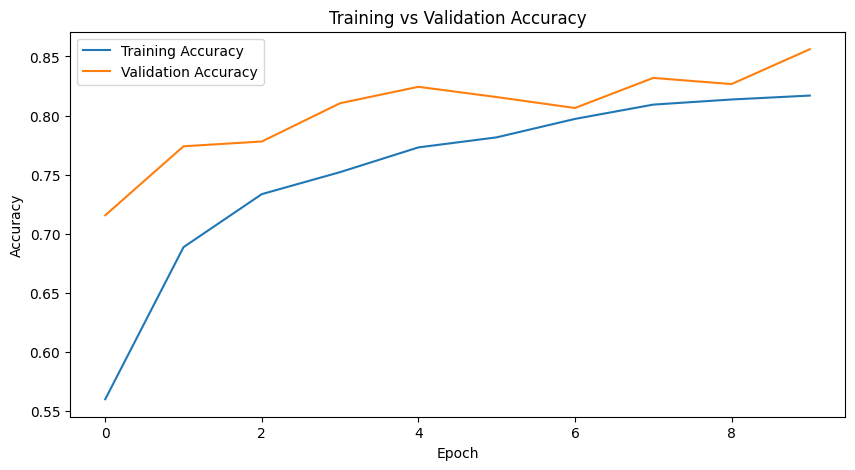

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.show()

#### Training and Validation Loss

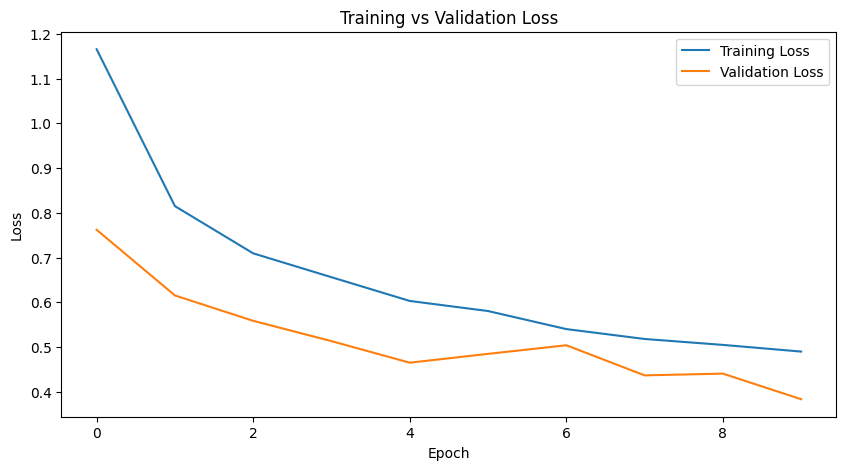

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.show()

#### Save Training Performance Visualizations

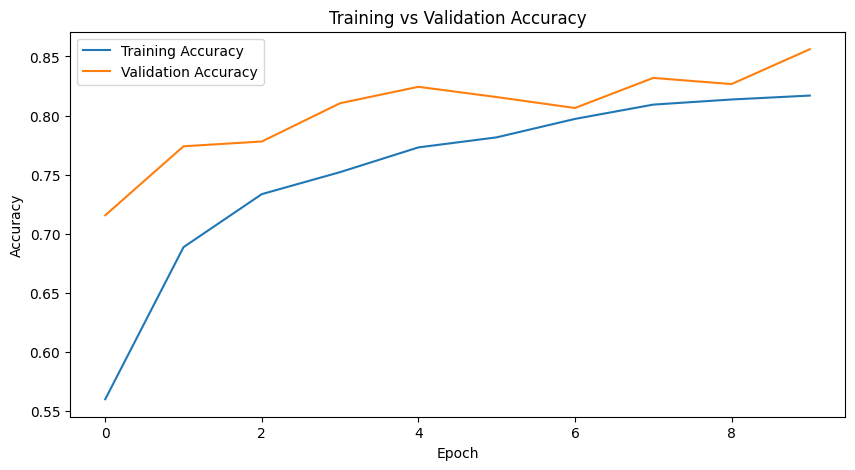

In [24]:
# Save accuracy plot
accuracy_plot_path = (
    MODEL_OUTPUT_DIR / "training_validation_accuracy.png"
)

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.savefig(
    accuracy_plot_path,
    bbox_inches="tight"
)

plt.show()

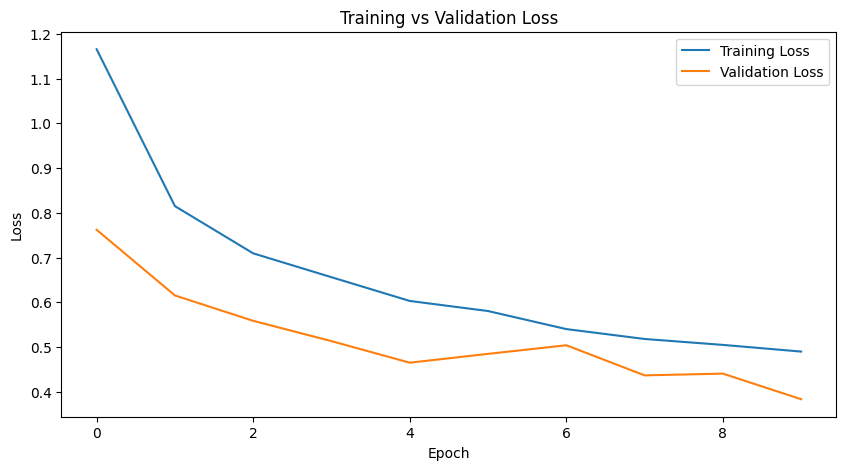

In [25]:
# Save loss plot
loss_plot_path = (
    MODEL_OUTPUT_DIR / "training_validation_loss.png"
)

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.savefig(
    loss_plot_path,
    bbox_inches="tight"
)

plt.show()

#### Observations

- Both training and validation accuracy improved steadily during training, indicating successful model learning.
- Validation accuracy remained slightly higher than training accuracy throughout most epochs, suggesting effective regularization and augmentation.
- Training and validation loss decreased consistently without large divergence between curves.
- The model demonstrated stable convergence and no strong evidence of severe overfitting.
- The training results suggest that transfer learning with MobileNetV2 provides a suitable baseline architecture for rice leaf disease classification.